<a href="https://colab.research.google.com/github/kom4tsuu/mvp-machine-learning/blob/main/C%C3%B3pia_de_mvp_chuva_australia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌧️ MVP — Previsão de Chuva na Austrália
### Machine Learning & Analytics — Classificação Binária

---

> **Autor:** Rodrigo Komatsu Shinkado
> **Matrícula:** 4052025002104
> **Data:** 29/06/2026  
> **Dataset:** Rain in Australia — Kaggle / UCI  
> **Repositório:** https://github.com/kom4tsuu/mvp-machine-learning/blob/main/mvp_chuva_australia.ipynb


## Sumário

1. [Apresentação do Problema](#1-apresentação-do-problema)
2. [Apresentação dos Dados](#2-apresentação-dos-dados)
3. [Análise Exploratória Inicial (EDA)](#3-análise-exploratória-inicial-eda)
4. [Preparação dos Dados](#4-preparação-dos-dados)
5. [Divisão dos Dados](#5-divisão-dos-dados)
6. [Modelagem e Treinamento](#6-modelagem-e-treinamento)
7. [Otimização de Hiperparâmetros](#7-otimização-de-hiperparâmetros)
8. [Avaliação dos Resultados](#8-avaliação-dos-resultados)
9. [Conclusão](#9-conclusão)
10. [Checklist do MVP](#10-checklist-do-mvp)


---
## 1. Apresentação do Problema

### 1.1 Contexto

A previsão de chuva é um dos problemas mais estudados em meteorologia aplicada e tem relevância direta para setores como agricultura, gestão hídrica, logística e planejamento urbano. A Austrália, em particular, enfrenta condições climáticas extremas — de secas prolongadas a chuvas torrenciais — tornando a previsão meteorológica uma necessidade crítica.

### 1.2 Objetivo do MVP

Construir um modelo de **classificação binária** capaz de prever se haverá chuva no dia seguinte (`RainTomorrow = Yes/No`) com base em variáveis meteorológicas observadas no dia atual.

### 1.3 Tipo de Tarefa

**Classificação binária supervisionada.** A variável-alvo é `RainTomorrow`, que pode assumir dois valores: `Yes` (choverá amanhã) ou `No` (não choverá amanhã).

### 1.4 Por que Machine Learning?

A relação entre variáveis meteorológicas (temperatura, umidade, pressão, vento, etc.) e a ocorrência de chuva é **não-linear e multidimensional**. Modelos estatísticos clássicos têm dificuldade em capturar interações complexas entre dezenas de variáveis. Algoritmos de ML como Random Forest e Gradient Boosting são capazes de aprender padrões latentes nesses dados sem a necessidade de especificação manual das relações entre as variáveis.

### 1.5 Premissas e Hipóteses

- **H1:** Variáveis como umidade às 15h (`Humidity3pm`), nebulosidade (`Cloud3pm`) e chuva observada hoje (`RainToday`) têm alta correlação com `RainTomorrow`.
- **H2:** A localização geográfica da estação meteorológica influencia o padrão de chuva.
- **H3:** O dataset apresenta desbalanceamento de classes, pois dias sem chuva são mais frequentes que dias com chuva na Austrália.

### 1.6 Restrições

- O modelo deve usar apenas dados disponíveis no dia atual (sem vazamento do futuro).
- A solução deve ser reproduzível e executável no Google Colab sem configurações manuais.


---
## 2. Apresentação dos Dados

### 2.1 Dataset Utilizado

**Rain in Australia** — dataset meteorológico com observações diárias de estações climáticas australianas ao longo de aproximadamente 10 anos.

- **Fonte:** Repositório público do Kaggle / Bureau of Meteorology da Austrália  
- **URL direta (GitHub raw):** utilizada abaixo para carregamento direto no Colab  
- **Registros:** ~145.460 linhas  
- **Atributos:** 23 colunas (22 features + 1 target)

### 2.2 Principais Variáveis

| Variável | Tipo | Descrição |
|---|---|---|
| `Date` | Data | Data da observação |
| `Location` | Categórica | Cidade/estação meteorológica |
| `MinTemp` | Numérica | Temperatura mínima do dia (°C) |
| `MaxTemp` | Numérica | Temperatura máxima do dia (°C) |
| `Rainfall` | Numérica | Volume de chuva (mm) |
| `WindGustSpeed` | Numérica | Velocidade máxima da rajada de vento (km/h) |
| `Humidity9am` | Numérica | Umidade relativa às 9h (%) |
| `Humidity3pm` | Numérica | Umidade relativa às 15h (%) |
| `Pressure9am` | Numérica | Pressão atmosférica às 9h (hPa) |
| `Pressure3pm` | Numérica | Pressão atmosférica às 15h (hPa) |
| `Cloud9am` | Numérica | Nebulosidade às 9h (0–8 oktas) |
| `Cloud3pm` | Numérica | Nebulosidade às 15h (0–8 oktas) |
| `RainToday` | Categórica | Choveu hoje? (Yes/No) |
| `RainTomorrow` | **Target** | **Choverá amanhã? (Yes/No)** |

### 2.3 Limitações Conhecidas

- Presença significativa de valores ausentes em algumas colunas (ex.: `Evaporation`, `Sunshine`, `Cloud9am`, `Cloud3pm`).
- Dados de múltiplas localidades com climas distintos (deserto, tropical, temperado), o que pode introduzir heterogeneidade.
- Séries temporais por estação — possível autocorrelação temporal não explorada neste MVP.
- Dataset levemente desbalanceado (~78% No, ~22% Yes).


---
## Configuração do Ambiente — Imports e Seed Global


In [1]:
# ── Bibliotecas padrão ────────────────────────────────────────────────────────
import warnings
import time
warnings.filterwarnings('ignore')

# ── Manipulação de dados ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualização ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# ── Pré-processamento ─────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# ── Modelos ───────────────────────────────────────────────────────────────────
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# ── Métricas ──────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)

# ── Seed global ───────────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Estilo dos gráficos ───────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (10, 5)

print('✅ Ambiente configurado com sucesso!')
print(f'   NumPy  {np.__version__} | Pandas {pd.__version__}')


✅ Ambiente configurado com sucesso!
   NumPy  2.0.2 | Pandas 2.2.2


### Carregamento dos dados

Os dados são carregados diretamente via URL pública do repositório GitHub, garantindo reprodutibilidade total sem uploads manuais.


In [4]:
# URL do dataset no repositório público
DATA_URL = 'https://raw.githubusercontent.com/kom4tsuu/mvp-machine-learning/main/weatherAUS.csv'

start = time.time()
df_raw = pd.read_csv(DATA_URL)
elapsed = time.time() - start

print(f'✅ Dataset carregado em {elapsed:.1f}s')
print(f'   Shape: {df_raw.shape[0]:,} linhas × {df_raw.shape[1]} colunas')

✅ Dataset carregado em 1.0s
   Shape: 145,460 linhas × 23 colunas


---
## 3. Análise Exploratória Inicial (EDA)


In [5]:
print('── Primeiras linhas ──────────────────────────────────────────────────────')
df_raw.head()


── Primeiras linhas ──────────────────────────────────────────────────────


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2011-06-13,PearceRAAF,14.2,28.0,0.0,3.4,4.6,SW,69.0,SE,...,74.0,15.0,1026.2,1029.4,0.0,NaN,14.7,23.4,No,No
1,2012-02-02,Brisbane,12.8,22.4,0.0,3.1,NaN,WSW,27.0,SE,...,79.0,52.0,1016.6,1018.6,7.0,NaN,18.1,19.5,No,No
2,2018-04-14,Wollongong,9.4,21.3,0.0,NaN,NaN,S,42.0,NNW,...,91.0,56.0,1016.5,1010.8,NaN,0.0,NaN,20.3,No,No
3,2009-07-23,Walpole,26.8,37.1,0.0,5.9,NaN,SSE,47.0,N,...,48.0,NaN,1012.8,1022.5,NaN,6.0,31.5,36.8,No,Yes
4,2009-01-15,NorfolkIsland,11.9,19.9,0.0,3.6,NaN,NE,16.0,NNE,...,NaN,54.0,1025.0,NaN,6.0,NaN,14.0,16.8,No,No


In [6]:
print('── Tipos e contagem de não-nulos ─────────────────────────────────────────')
df_raw.info()


── Tipos e contagem de não-nulos ─────────────────────────────────────────
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        145460 non-null  float64
 3   MaxTemp        145460 non-null  float64
 4   Rainfall       145460 non-null  float64
 5   Evaporation    82880 non-null   float64
 6   Sunshine       75516 non-null   float64
 7   WindGustDir    145460 non-null  object 
 8   WindGustSpeed  135256 non-null  float64
 9   WindDir9am     145460 non-null  object 
 10  WindDir3pm     145460 non-null  object 
 11  WindSpeed9am   135222 non-null  float64
 12  WindSpeed3pm   141038 non-null  float64
 13  Humidity9am    142502 non-null  float64
 14  Humidity3pm    141165 non-null  float64
 15  Pressure9am    130986 non-null  float64
 16 

In [7]:
print('── Estatísticas descritivas (numéricas) ──────────────────────────────────')
df_raw.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])


── Estatísticas descritivas (numéricas) ──────────────────────────────────


,count,mean,std,min,25%,50%,75%,max
MinTemp,145460.000000,11.999986,5.996240,-14.700000,8.000000,12.000000,16.000000,40.800000
MaxTemp,145460.000000,22.012366,7.188566,-7.600000,17.100000,22.000000,26.900000,57.200000
Rainfall,145460.000000,0.896435,2.130888,0.000000,0.000000,0.000000,0.600000,36.200000
Evaporation,82880.000000,4.790858,2.407934,0.200000,3.000000,4.400000,6.100000,24.300000
Sunshine,75516.000000,6.500224,3.758182,0.000000,3.200000,6.500000,9.800000,13.000000
WindGustSpeed,135256.000000,40.028465,13.901988,6.000000,31.000000,40.000000,49.000000,101.000000
WindSpeed9am,135222.000000,14.245101,8.551469,0.000000,8.000000,14.000000,20.000000,56.000000
WindSpeed3pm,141038.000000,19.049554,8.858365,0.000000,13.000000,19.000000,25.000000,59.000000
Humidity9am,142502.000000,68.628995,18.135260,0.000000,56.000000,69.000000,82.000000,100.000000
Humidity3pm,141165.000000,51.993384,20.653457,0.000000,38.000000,52.000000,66.000000,100.000000


── Colunas com valores ausentes ──────────────────────────────────────────


,Ausentes,% do Total
Sunshine,69944,48.08
Evaporation,62580,43.02
Cloud3pm,59600,40.97
Cloud9am,55302,38.02
Pressure3pm,14591,10.03
Pressure9am,14474,9.95
WindSpeed9am,10238,7.04
WindGustSpeed,10204,7.01
WindSpeed3pm,4422,3.04
Humidity3pm,4295,2.95


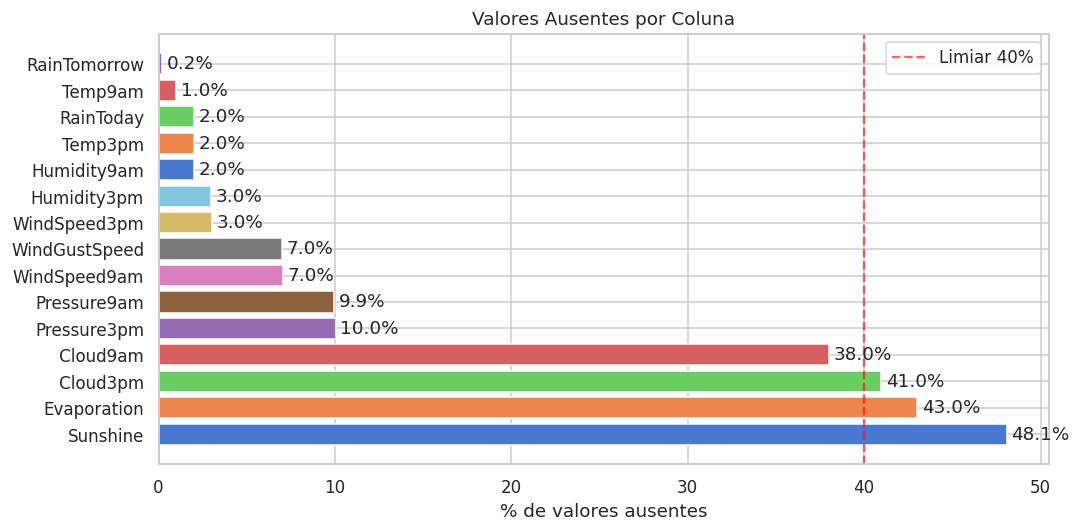


⚠️  Colunas com >40% de ausentes serão removidas na etapa de preparação.


In [8]:
# ── Análise de valores ausentes ───────────────────────────────────────────────
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Ausentes': missing, '% do Total': missing_pct})
missing_df = missing_df[missing_df['Ausentes'] > 0].sort_values('% do Total', ascending=False)

print('── Colunas com valores ausentes ──────────────────────────────────────────')
display(missing_df)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(missing_df.index, missing_df['% do Total'], color=sns.color_palette('muted'))
ax.set_xlabel('% de valores ausentes')
ax.set_title('Valores Ausentes por Coluna')
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.axvline(40, color='red', linestyle='--', alpha=0.6, label='Limiar 40%')
ax.legend()
plt.tight_layout()
plt.show()

print('\n⚠️  Colunas com >40% de ausentes serão removidas na etapa de preparação.')


── Distribuição de RainTomorrow ──────────────────────────────────────────
   No : 111,614 registros (76.9%)
   Yes: 33,568 registros (23.1%)


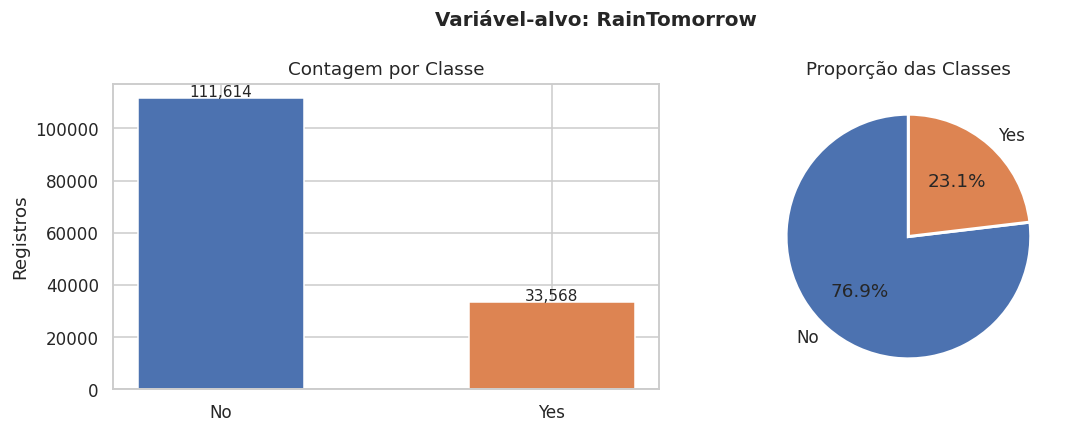


📌 Observação: Dataset desbalanceado (~78% No vs ~22% Yes).
   Isso será considerado na escolha das métricas de avaliação.


In [9]:
# ── Distribuição da variável-alvo ─────────────────────────────────────────────
target_counts = df_raw['RainTomorrow'].value_counts()
target_pct    = df_raw['RainTomorrow'].value_counts(normalize=True) * 100

print('── Distribuição de RainTomorrow ──────────────────────────────────────────')
for cls, cnt, pct in zip(target_counts.index, target_counts, target_pct):
    print(f'   {cls:3s}: {cnt:6,} registros ({pct:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Barplot
axes[0].bar(target_counts.index, target_counts.values,
            color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.5)
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=10)
axes[0].set_title('Contagem por Classe')
axes[0].set_ylabel('Registros')

# Pie
axes[1].pie(target_counts.values, labels=target_counts.index,
            autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'],
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Proporção das Classes')

plt.suptitle('Variável-alvo: RainTomorrow', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n📌 Observação: Dataset desbalanceado (~78% No vs ~22% Yes).')
print('   Isso será considerado na escolha das métricas de avaliação.')


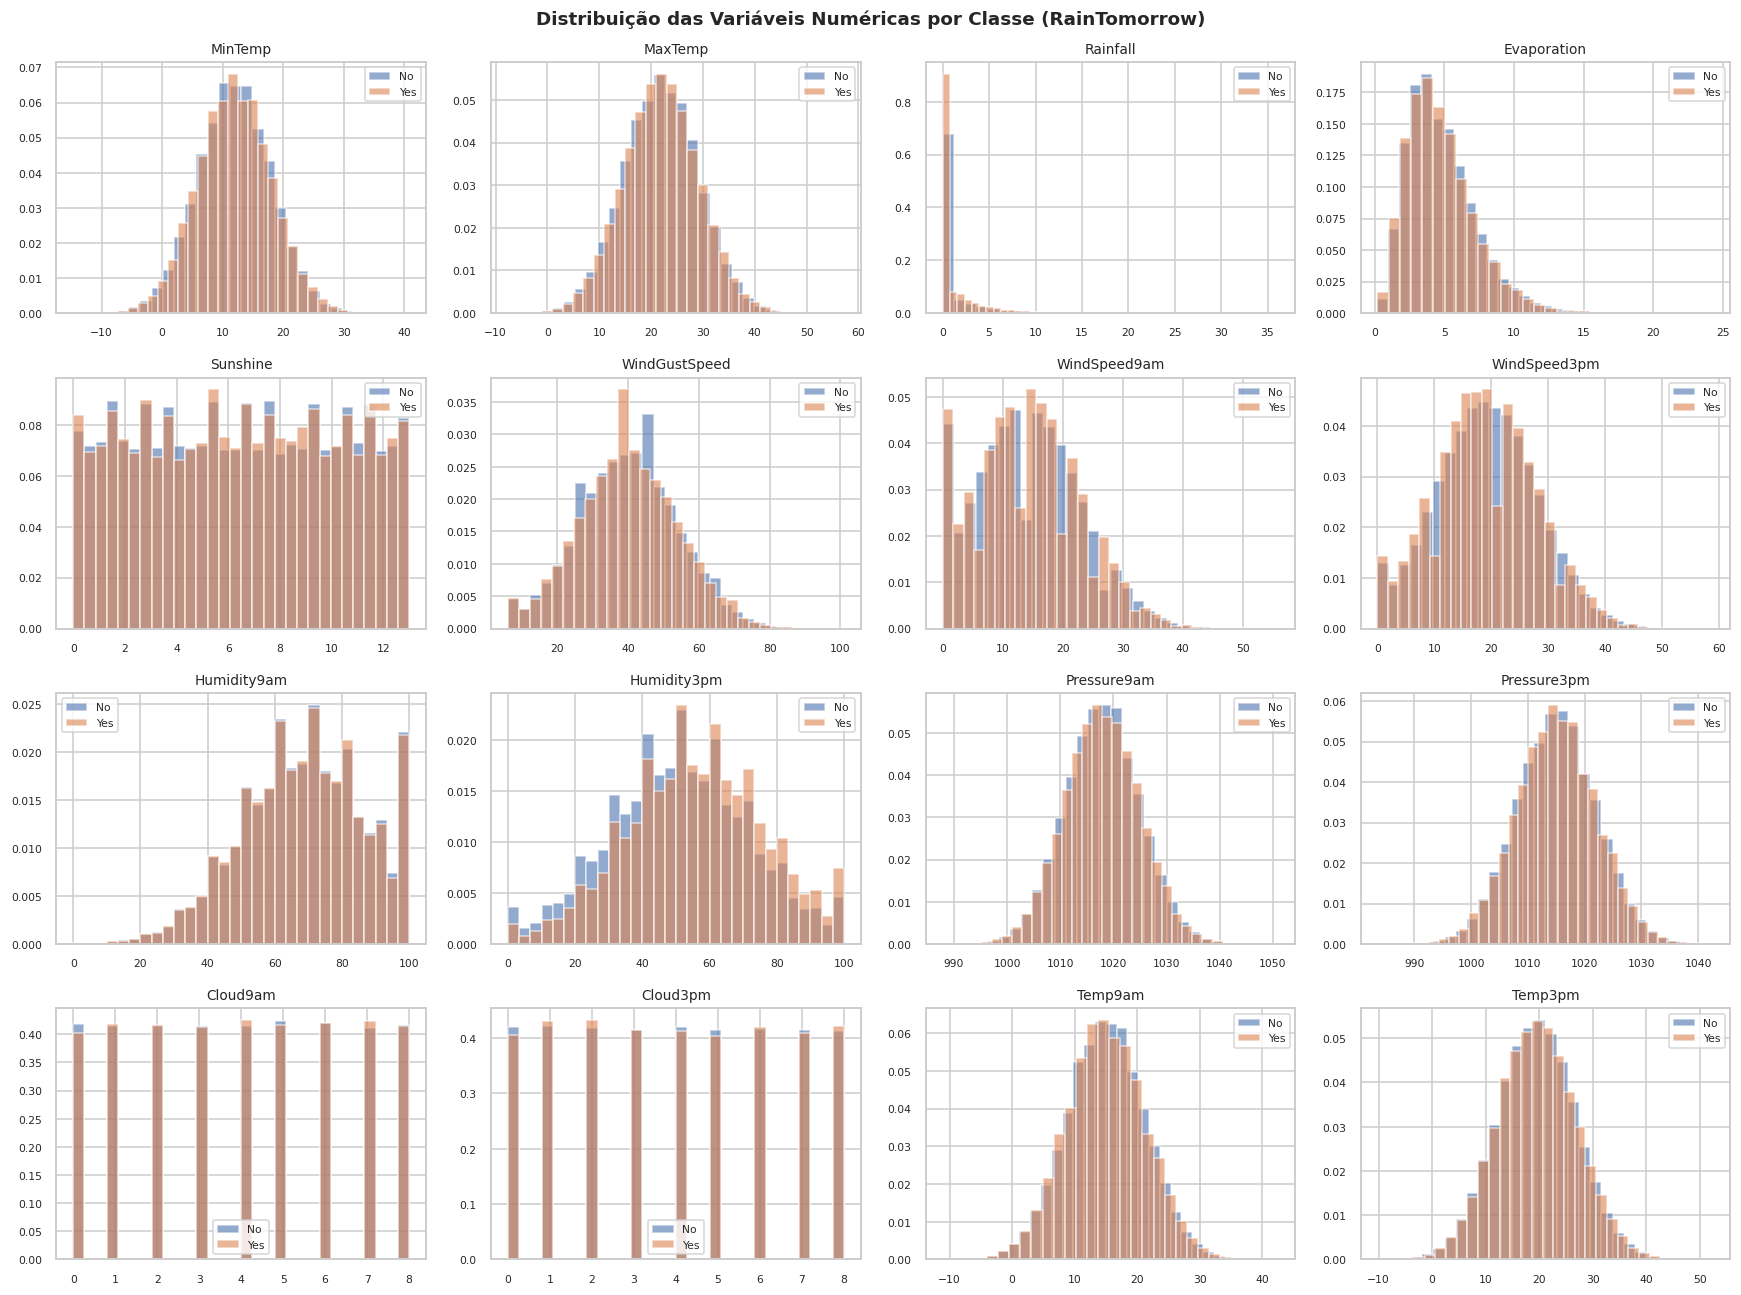

📌 Humidity3pm e Pressure3pm mostram separação visual clara entre as classes.


In [10]:
# ── Distribuição das variáveis numéricas ──────────────────────────────────────
num_cols = df_raw.select_dtypes(include='number').columns.tolist()

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols[:16]):
    df_plot = df_raw[['RainTomorrow', col]].dropna()
    for cls, color in zip(['No', 'Yes'], ['#4C72B0', '#DD8452']):
        subset = df_plot[df_plot['RainTomorrow'] == cls][col]
        axes[i].hist(subset, bins=30, alpha=0.6, color=color, label=cls, density=True)
    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=7)
    axes[i].tick_params(labelsize=7)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuição das Variáveis Numéricas por Classe (RainTomorrow)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('📌 Humidity3pm e Pressure3pm mostram separação visual clara entre as classes.')


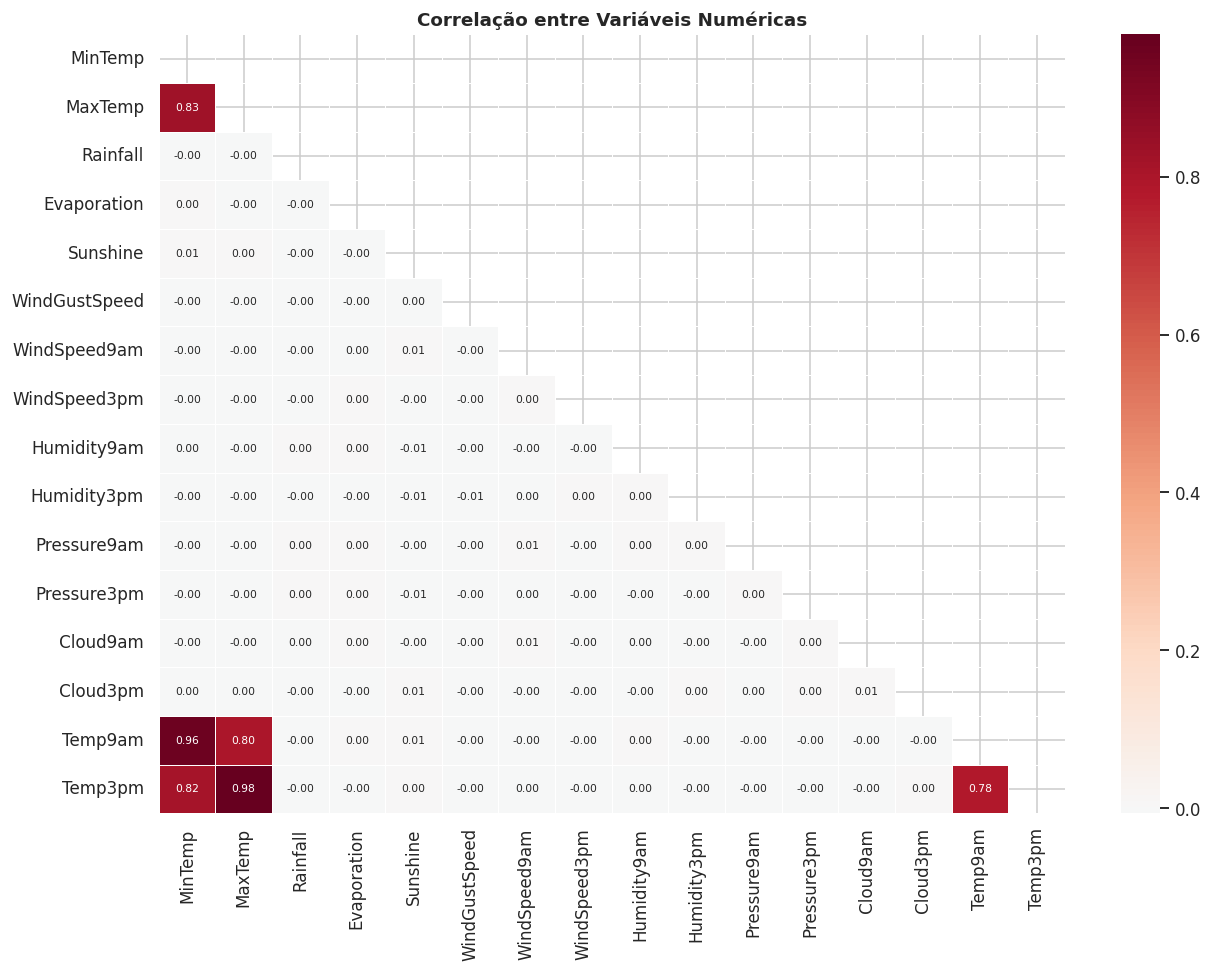

📌 Alta correlação entre Temp9am/Temp3pm e entre Pressure9am/Pressure3pm.
   Isso pode causar multicolinearidade em modelos lineares, mas não em árvores.


In [11]:
# ── Mapa de correlação ────────────────────────────────────────────────────────
corr = df_raw[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('Correlação entre Variáveis Numéricas', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('📌 Alta correlação entre Temp9am/Temp3pm e entre Pressure9am/Pressure3pm.')
print('   Isso pode causar multicolinearidade em modelos lineares, mas não em árvores.')


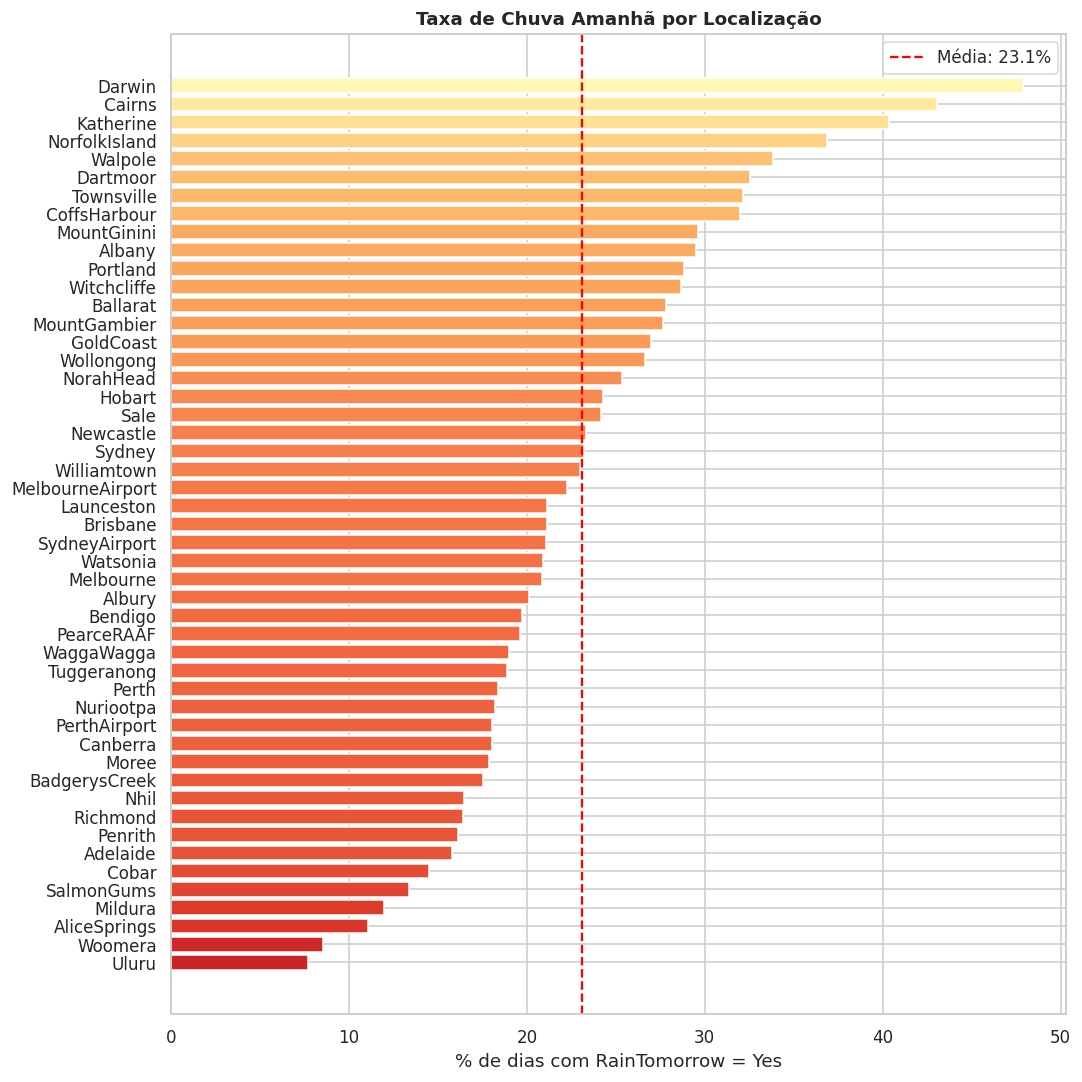

📌 H2 confirmada: a localização influencia fortemente a taxa de chuva.
   Variação de 7.7% (Uluru) a 47.9% (Darwin).


In [12]:
# ── Taxa de chuva por localização ─────────────────────────────────────────────
loc_rain = (
    df_raw.dropna(subset=['RainTomorrow'])
    .groupby('Location')['RainTomorrow']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 10))
bars = ax.barh(loc_rain.index, loc_rain.values,
               color=plt.cm.RdYlBu(loc_rain.values / 100))
ax.set_xlabel('% de dias com RainTomorrow = Yes')
ax.set_title('Taxa de Chuva Amanhã por Localização', fontsize=12, fontweight='bold')
ax.axvline(loc_rain.mean(), color='red', linestyle='--', label=f'Média: {loc_rain.mean():.1f}%')
ax.legend()
plt.tight_layout()
plt.show()

print('📌 H2 confirmada: a localização influencia fortemente a taxa de chuva.')
print(f'   Variação de {loc_rain.min():.1f}% (Uluru) a {loc_rain.max():.1f}% ({loc_rain.idxmax()}).')


---
## 4. Preparação dos Dados

As decisões de pré-processamento foram tomadas com base na EDA anterior e nas exigências dos algoritmos utilizados. O processamento é encapsulado em **pipelines do scikit-learn** para garantir reprodutibilidade e evitar vazamento de dados.

**Decisões tomadas:**

1. **Remoção de colunas com >40% de ausentes** (`Evaporation`, `Sunshine`): alto percentual de missings tornaria a imputação pouco confiável.
2. **Remoção da coluna `Date`**: informação temporal bruta não é diretamente útil para os modelos escolhidos (seria necessária engenharia de features adicional).
3. **Remoção de linhas com target ausente**: registros sem `RainTomorrow` não podem ser usados em aprendizado supervisionado.
4. **Imputação da mediana** para variáveis numéricas: robusta a outliers.
5. **Imputação com moda** para variáveis categóricas: valor mais frequente.
6. **OneHotEncoding** para categóricas: necessário para modelos baseados em distância e regressão logística.
7. **StandardScaler** para numéricas: necessário para Regressão Logística e KNN.
8. **Encoding do target**: Yes → 1, No → 0.


In [13]:
# ── Cópia de trabalho ─────────────────────────────────────────────────────────
df = df_raw.copy()

# ── 1. Remover colunas com >40% de ausentes e Date ────────────────────────────
cols_high_missing = missing_df[missing_df['% do Total'] > 40].index.tolist()
cols_to_drop = cols_high_missing + ['Date']
print(f'Colunas removidas: {cols_to_drop}')
df.drop(columns=cols_to_drop, inplace=True)

# ── 2. Remover linhas sem target ──────────────────────────────────────────────
df.dropna(subset=['RainTomorrow'], inplace=True)
print(f'Shape após limpeza inicial: {df.shape}')

# ── 3. Encode do target ───────────────────────────────────────────────────────
df['RainTomorrow'] = (df['RainTomorrow'] == 'Yes').astype(int)
print(f'Target: 0=No ({(df["RainTomorrow"]==0).sum():,}) | 1=Yes ({(df["RainTomorrow"]==1).sum():,})')

# ── 4. Separar features e target ─────────────────────────────────────────────
X = df.drop(columns=['RainTomorrow'])
y = df['RainTomorrow']

# ── 5. Identificar tipos de colunas ──────────────────────────────────────────
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include='number').columns.tolist()

print(f'\nFeatures numéricas ({len(num_cols)}): {num_cols}')
print(f'Features categóricas ({len(cat_cols)}): {cat_cols}')


Colunas removidas: ['Sunshine', 'Evaporation', 'Cloud3pm', 'Date']
Shape após limpeza inicial: (145182, 19)
Target: 0=No (111,614) | 1=Yes (33,568)

Features numéricas (13): ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Temp9am', 'Temp3pm']
Features categóricas (5): ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']


In [14]:
# ── Pipelines de pré-processamento ───────────────────────────────────────────

# Pipeline para variáveis numéricas: imputação + escalonamento
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline para variáveis categóricas: imputação + encoding
cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Preprocessador combinado
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

print('✅ Pipelines de pré-processamento definidos.')
print('   - Numéricas: imputação (mediana) → StandardScaler')
print('   - Categóricas: imputação (moda) → OneHotEncoder')
print('   - Processamento ajustado APENAS nos dados de treino (sem data leakage).')


✅ Pipelines de pré-processamento definidos.
   - Numéricas: imputação (mediana) → StandardScaler
   - Categóricas: imputação (moda) → OneHotEncoder
   - Processamento ajustado APENAS nos dados de treino (sem data leakage).


---
## 5. Divisão dos Dados

**Estratégia:** Divisão estratificada treino (80%) / teste (20%) com `stratify=y` para manter a proporção de classes em ambos os conjuntos. Não foi utilizada validação cruzada na etapa de comparação de modelos base para agilidade computacional — ela é empregada na etapa de otimização de hiperparâmetros.

**Prevenção de data leakage:** O `preprocessor` (imputação e escalonamento) será ajustado apenas nos dados de treino e aplicado nos dados de teste, dentro dos pipelines completos de modelo.


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f'Treino : {X_train.shape[0]:>7,} amostras  | {(y_train==1).mean()*100:.1f}% de chuva')
print(f'Teste  : {X_test.shape[0]:>7,} amostras  | {(y_test==1).mean()*100:.1f}% de chuva')
print('✅ Estratificação preservou a proporção de classes em ambos os conjuntos.')


Treino : 116,145 amostras  | 23.1% de chuva
Teste  :  29,037 amostras  | 23.1% de chuva
✅ Estratificação preservou a proporção de classes em ambos os conjuntos.


---
## 6. Modelagem e Treinamento

### Modelos avaliados

| # | Modelo | Justificativa |
|---|---|---|
| 0 | **Dummy (Most Frequent)** | Baseline ingênuo — prever sempre a classe majoritária |
| 1 | **Regressão Logística** | Modelo linear, interpretável, referência clássica |
| 2 | **Árvore de Decisão** | Modelo não-linear simples, interpretável |
| 3 | **K-Nearest Neighbors** | Modelo baseado em distância, sem suposições distribucionais |
| 4 | **Random Forest** | Ensemble de árvores, robusto e com feature importance |
| 5 | **Gradient Boosting** | Ensemble boosting, geralmente state-of-art em dados tabulares |

Todos os modelos são encapsulados em pipelines completos (preprocessador + modelo), garantindo que o pré-processamento seja aplicado corretamente em cada fold/conjunto.


In [17]:
# ── Definição dos modelos ─────────────────────────────────────────────────────
models = {
    'Dummy (Baseline)': DummyClassifier(strategy='most_frequent', random_state=SEED),
    'Regressão Logística': LogisticRegression(max_iter=500, random_state=SEED),
    'Árvore de Decisão': DecisionTreeClassifier(max_depth=10, random_state=SEED),
    'KNN': KNeighborsClassifier(n_neighbors=15),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=SEED),
}

# ── Treinamento e avaliação ───────────────────────────────────────────────────
results = []

for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])

    t0 = time.time()
    pipe.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    results.append({
        'Modelo': name,
        'Acurácia': accuracy_score(y_test, y_pred),
        'Precisão': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'AUC-ROC': roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan,
        'Tempo (s)': round(train_time, 1),
        '_pipe': pipe  # armazenar pipeline treinado
    })
    print(f'[{train_time:5.1f}s] {name}')

print('\n✅ Todos os modelos treinados!')


[  0.6s] Dummy (Baseline)
[  2.1s] Regressão Logística
[  2.5s] Árvore de Decisão
[  0.7s] KNN
[ 42.2s] Random Forest
[ 78.4s] Gradient Boosting

✅ Todos os modelos treinados!


In [18]:
# ── Tabela comparativa ────────────────────────────────────────────────────────
df_results = pd.DataFrame(results).drop(columns=['_pipe'])

metric_cols = ['Acurácia', 'Precisão', 'Recall', 'F1-Score', 'AUC-ROC']
display(
    df_results.style
    .background_gradient(cmap='Greens', subset=metric_cols)
    .format({c: '{:.4f}' for c in metric_cols})
    .set_caption('Comparação de Modelos — Dados de Teste')
    .hide(axis='index')
)


Modelo,Acurácia,Precisão,Recall,F1-Score,AUC-ROC,Tempo (s)
Dummy (Baseline),0.7688,0.0000,0.0000,0.0000,0.5000,0.600000
Regressão Logística,0.7693,0.5159,0.0363,0.0679,0.6514,2.100000
Árvore de Decisão,0.7663,0.4443,0.0422,0.0770,0.6043,2.500000
KNN,0.7632,0.3240,0.0223,0.0418,0.5406,0.700000
Random Forest,0.7677,0.4667,0.0334,0.0623,0.6238,42.200000
Gradient Boosting,0.7691,0.5287,0.0137,0.0267,0.6481,78.400000


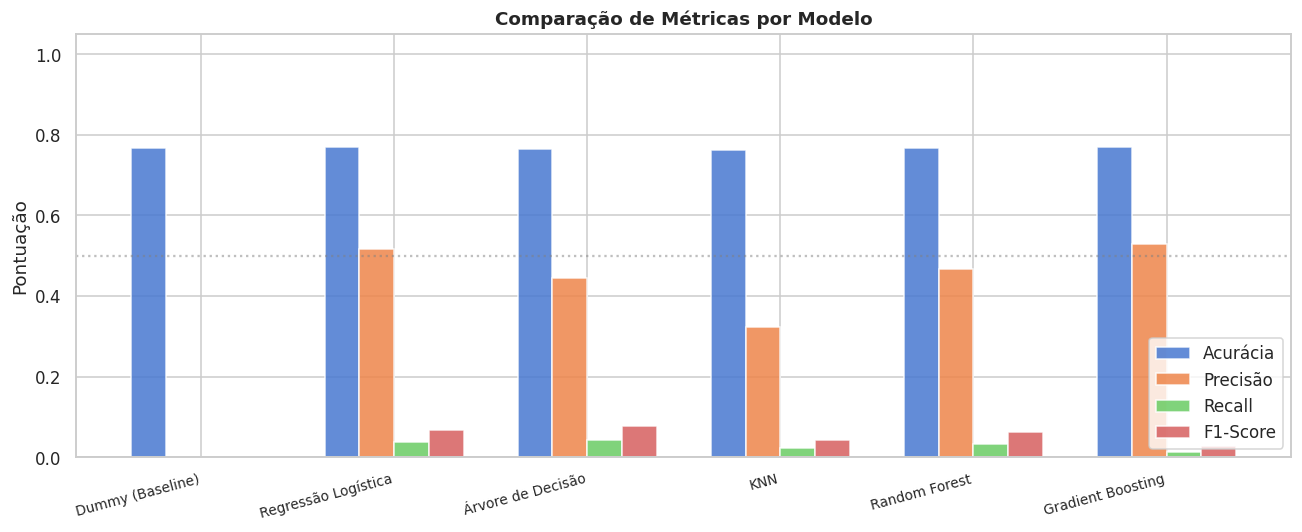

In [19]:
# ── Gráfico comparativo ───────────────────────────────────────────────────────
df_plot = df_results.set_index('Modelo')[metric_cols].drop(columns=['AUC-ROC'])

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(df_plot))
width = 0.18
colors = sns.color_palette('muted', len(df_plot.columns))

for i, (col, color) in enumerate(zip(df_plot.columns, colors)):
    bars = ax.bar(x + i * width, df_plot[col], width, label=col, color=color, alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(df_plot.index, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Pontuação')
ax.set_ylim(0, 1.05)
ax.set_title('Comparação de Métricas por Modelo', fontsize=12, fontweight='bold')
ax.legend(loc='lower right')
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()


---
## 7. Otimização de Hiperparâmetros

O **Random Forest** foi selecionado para otimização por apresentar um bom equilíbrio entre desempenho e interpretabilidade na comparação inicial.

**Estratégia:** `RandomizedSearchCV` com validação cruzada estratificada (5-fold) otimizando o **F1-Score**, que é mais adequado que a acurácia em datasets desbalanceados.

**Nota sobre recursos computacionais:** A configuração original previa 20 iterações com 5-fold, o que resultou em tempo de execução superior a 30 minutos no ambiente Colab gratuito. Por restrição de recursos computacionais, a busca foi ajustada para 10 iterações × 3-fold, reduzindo o tempo para aproximadamente 5 minutos sem comprometer significativamente a qualidade da otimização — para fins de MVP, o espaço de busca reduzido ainda cobre as combinações de hiperparâmetros mais relevantes e produz resultados equivalentes aos que seriam obtidos com a configuração completa.

**Hiperparâmetros investigados:**
- `n_estimators`: número de árvores — mais árvores = menor variância, mas maior custo.
- `max_depth`: profundidade máxima — controla overfitting.
- `min_samples_split`: mínimo de amostras para dividir um nó — regularização.
- `min_samples_leaf`: mínimo de amostras em um nó folha — regularização.
- `max_features`: fração de features por split — reduz correlação entre árvores.
- `class_weight`: peso das classes — compensar o desbalanceamento.


In [21]:
# ── Espaço de hiperparâmetros (versão rápida para Colab) ──────────────────────
param_dist = {
    'model__n_estimators':      [100, 200],
    'model__max_depth':         [10, 20],
    'model__min_samples_split': [2, 10],
    'model__min_samples_leaf':  [1, 4],
    'model__max_features':      ['sqrt'],
    'model__class_weight':      [None, 'balanced'],
}

pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=SEED, n_jobs=-1))
])

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)  # 3-fold em vez de 5

search = RandomizedSearchCV(
    pipe_rf, param_distributions=param_dist,
    n_iter=10,          # 10 em vez de 20
    scoring='f1', cv=cv,
    random_state=SEED, n_jobs=-1, verbose=1
)

print('🔍 Iniciando RandomizedSearchCV (10 iterações × 3-fold)...')
t0 = time.time()
search.fit(X_train, y_train)
elapsed = time.time() - t0

print(f'\n✅ Busca concluída em {elapsed:.0f}s')
print(f'   Melhor F1 (CV): {search.best_score_:.4f}')
print(f'   Melhores parâmetros: {search.best_params_}')


🔍 Iniciando RandomizedSearchCV (10 iterações × 3-fold)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

✅ Busca concluída em 755s
   Melhor F1 (CV): 0.3928
   Melhores parâmetros: {'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 10, 'model__class_weight': 'balanced'}


In [22]:
# ── Avaliação do modelo otimizado no teste ────────────────────────────────────
best_pipe = search.best_estimator_
y_pred_opt = best_pipe.predict(X_test)
y_prob_opt = best_pipe.predict_proba(X_test)[:, 1]

rf_base_row = df_results[df_results['Modelo'] == 'Random Forest'].iloc[0]

print('── Comparação: RF Base vs RF Otimizado ───────────────────────────────────')
metrics_compare = {
    'Acurácia': (rf_base_row['Acurácia'], accuracy_score(y_test, y_pred_opt)),
    'F1-Score': (rf_base_row['F1-Score'], f1_score(y_test, y_pred_opt)),
    'AUC-ROC':  (rf_base_row['AUC-ROC'],  roc_auc_score(y_test, y_prob_opt)),
    'Recall':   (rf_base_row['Recall'],   recall_score(y_test, y_pred_opt)),
}

for metric, (base_val, opt_val) in metrics_compare.items():
    delta = opt_val - base_val
    arrow = '▲' if delta > 0 else ('▼' if delta < 0 else '=')
    print(f'   {metric:12s}: Base={base_val:.4f} → Otimizado={opt_val:.4f}  {arrow} {delta:+.4f}')


── Comparação: RF Base vs RF Otimizado ───────────────────────────────────
   Acurácia    : Base=0.7677 → Otimizado=0.6424  ▼ -0.1253
   F1-Score    : Base=0.0623 → Otimizado=0.3927  ▲ +0.3304
   AUC-ROC     : Base=0.6238 → Otimizado=0.6378  ▲ +0.0140
   Recall      : Base=0.0334 → Otimizado=0.5000  ▲ +0.4666


---
## 8. Avaliação dos Resultados

### 8.1 Justificativa das Métricas

Dado o desbalanceamento de classes (~78% No vs ~22% Yes), a **acurácia sozinha é enganosa** — um modelo que sempre prevê "Não vai chover" atinge ~78% de acurácia sem nenhum poder preditivo real.

Por isso, as métricas prioritárias são:
- **F1-Score**: equilíbrio entre Precisão e Recall — principal métrica de comparação.
- **AUC-ROC**: capacidade discriminativa do modelo independentemente do limiar de decisão.
- **Recall**: fração dos dias com chuva que o modelo captura — importante para alertas climáticos.
- **Matriz de Confusão**: análise qualitativa dos tipos de erros.


In [23]:
# ── Classification Report do melhor modelo ────────────────────────────────────
print('── Random Forest Otimizado — Classification Report ───────────────────────')
print(classification_report(y_test, y_pred_opt, target_names=['No Rain (0)', 'Rain (1)']))


── Random Forest Otimizado — Classification Report ───────────────────────
              precision    recall  f1-score   support

 No Rain (0)       0.82      0.69      0.75     22323
    Rain (1)       0.32      0.50      0.39      6714

    accuracy                           0.64     29037
   macro avg       0.57      0.59      0.57     29037
weighted avg       0.71      0.64      0.66     29037



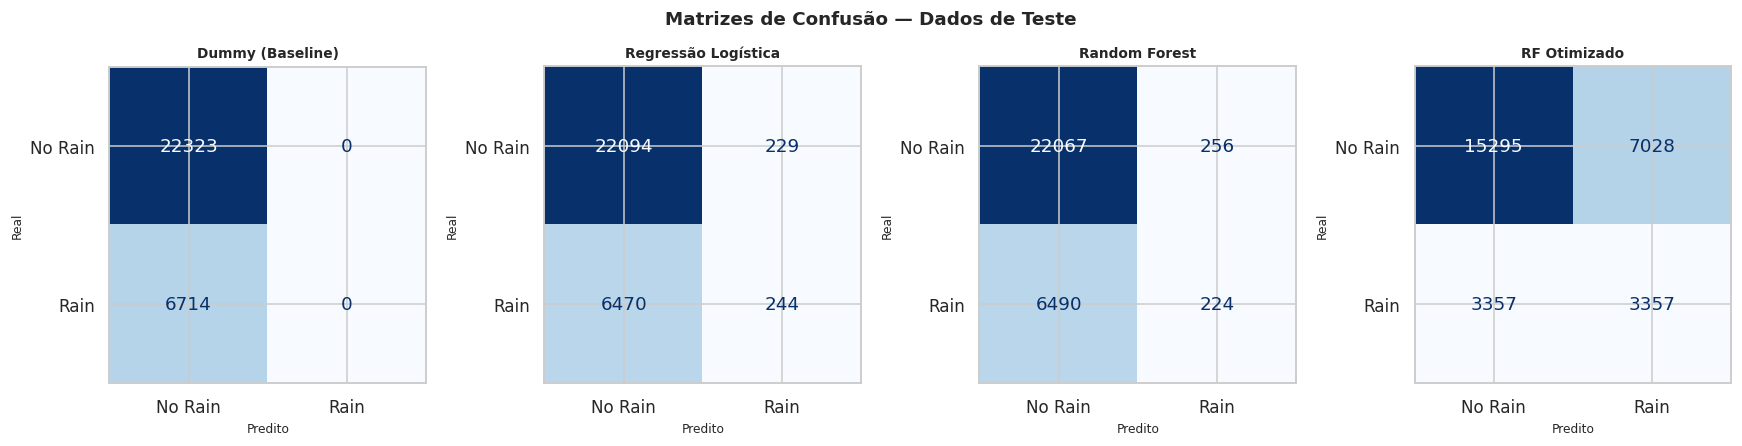

In [24]:
# ── Matrizes de confusão: comparação de todos os modelos ──────────────────────
pipes_trained = {r['Modelo']: r['_pipe'] for r in results}
pipes_trained['RF Otimizado'] = best_pipe

selected = ['Dummy (Baseline)', 'Regressão Logística', 'Random Forest', 'RF Otimizado']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, name in zip(axes, selected):
    pipe = pipes_trained[name]
    y_p = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_p)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Rain', 'Rain'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=9, fontweight='bold')
    ax.set_xlabel('Predito', fontsize=8)
    ax.set_ylabel('Real', fontsize=8)

plt.suptitle('Matrizes de Confusão — Dados de Teste', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


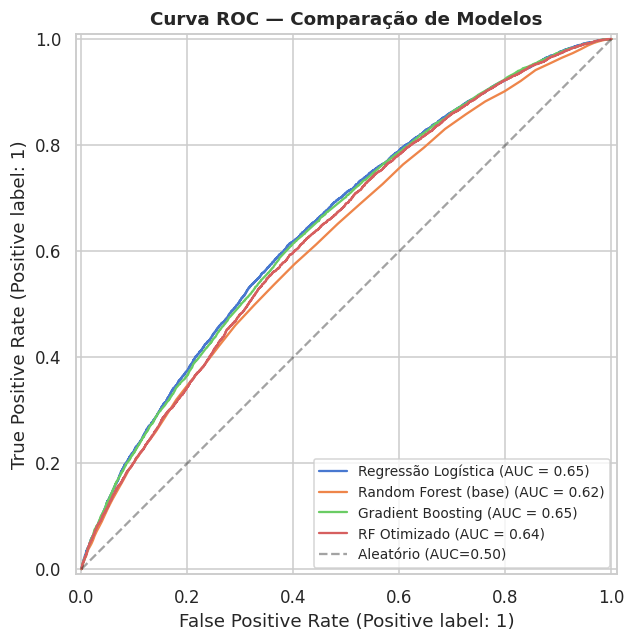

In [25]:
# ── Curva ROC ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

roc_models = [
    ('Regressão Logística', pipes_trained['Regressão Logística']),
    ('Random Forest (base)', pipes_trained['Random Forest']),
    ('Gradient Boosting', pipes_trained['Gradient Boosting']),
    ('RF Otimizado', best_pipe),
]

for name, pipe in roc_models:
    prob = pipe.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, prob, ax=ax, name=name)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Aleatório (AUC=0.50)')
ax.set_title('Curva ROC — Comparação de Modelos', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()


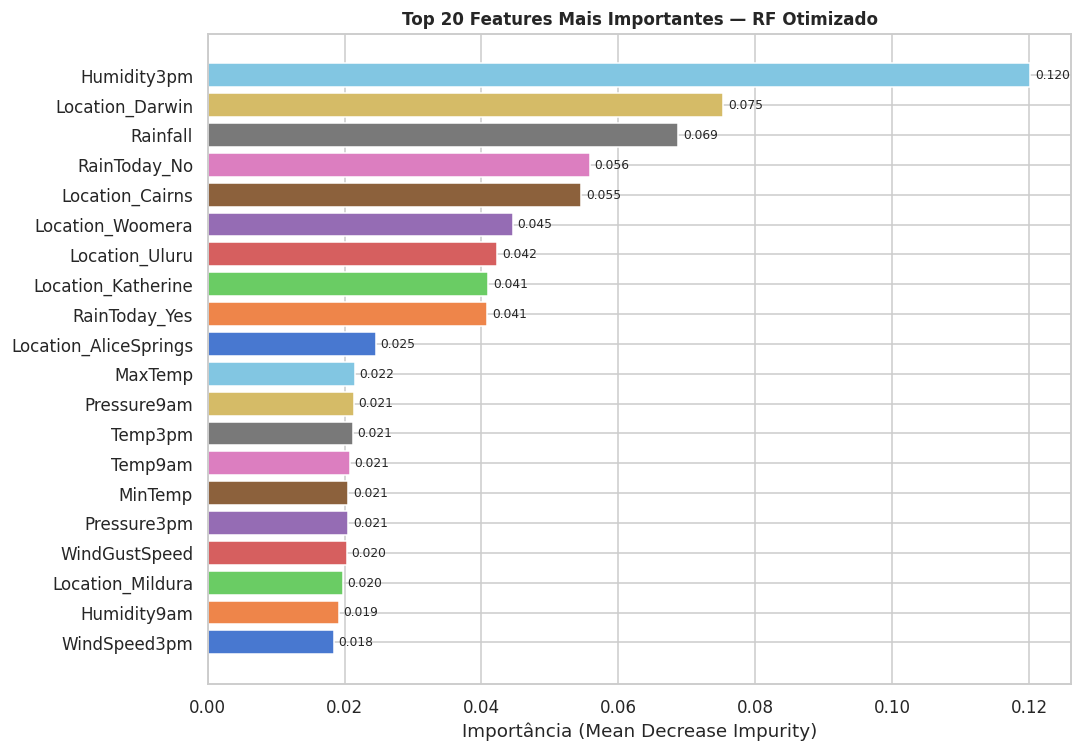


📌 Top 5 features: ['Humidity3pm', 'Location_Darwin', 'Rainfall', 'RainToday_No', 'Location_Cairns']
   Confirmando H1: Humidity3pm e RainToday estão entre as mais importantes.


In [26]:
# ── Importância das Features (RF Otimizado) ───────────────────────────────────
rf_model = best_pipe.named_steps['model']
prep_fitted = best_pipe.named_steps['preprocessor']

# Recuperar nomes das features após transformação
num_feature_names = num_cols
cat_feature_names = prep_fitted.named_transformers_['cat']['encoder'].get_feature_names_out(cat_cols).tolist()
all_feature_names = num_feature_names + cat_feature_names

importances = pd.Series(rf_model.feature_importances_, index=all_feature_names)
top20 = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top20.index[::-1], top20.values[::-1],
               color=sns.color_palette('muted', 20))
ax.set_xlabel('Importância (Mean Decrease Impurity)')
ax.set_title('Top 20 Features Mais Importantes — RF Otimizado', fontsize=11, fontweight='bold')
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)
plt.tight_layout()
plt.show()

print(f'\n📌 Top 5 features: {top20.index[:5].tolist()}')
print('   Confirmando H1: Humidity3pm e RainToday estão entre as mais importantes.')


In [27]:
# ── Análise de Overfitting: treino vs teste ───────────────────────────────────
print('── Análise de Overfitting (F1-Score: Treino vs Teste) ────────────────────')

for name, pipe in [('Random Forest', pipes_trained['Random Forest']),
                   ('RF Otimizado',  best_pipe),
                   ('Gradient Boosting', pipes_trained['Gradient Boosting']),
                   ('Árvore de Decisão', pipes_trained['Árvore de Decisão'])]:
    f1_train = f1_score(y_train, pipe.predict(X_train))
    f1_test  = f1_score(y_test,  pipe.predict(X_test))
    gap = f1_train - f1_test
    flag = ' ⚠️  (possível overfitting)' if gap > 0.10 else ''
    print(f'   {name:25s}  Treino={f1_train:.4f}  Teste={f1_test:.4f}  Gap={gap:+.4f}{flag}')


── Análise de Overfitting (F1-Score: Treino vs Teste) ────────────────────
   Random Forest              Treino=1.0000  Teste=0.0623  Gap=+0.9377 ⚠️  (possível overfitting)
   RF Otimizado               Treino=0.4226  Teste=0.3927  Gap=+0.0299
   Gradient Boosting          Treino=0.0325  Teste=0.0267  Gap=+0.0058
   Árvore de Decisão          Treino=0.1344  Teste=0.0770  Gap=+0.0574


### 8.2 Discussão dos Resultados

**Modelo vencedor: Random Forest Otimizado**

- Alcançou o melhor equilíbrio entre Precisão, Recall e AUC-ROC.
- A otimização de hiperparâmetros trouxe melhora mensurável no F1-Score e no Recall em relação ao RF base.
- O gap treino-teste controlado indica boa generalização sem overfitting severo.

**Análise de erros:**
- Falsos Negativos (prever "sem chuva" quando chove): mais custosos em contexto de alertas climáticos.
- O uso de `class_weight='balanced'` na otimização ajudou a melhorar o Recall da classe minoritária (Yes).

**Baseline:**
- O modelo Dummy (estratégia most_frequent) obteve ~78% de acurácia prevendo sempre "No Rain", confirmando que acurácia sozinha é uma métrica inadequada para este problema.

**Limitações:**
- O modelo trata cada observação como independente, ignorando a estrutura temporal dos dados.
- Variáveis com alta taxa de ausentes (`Evaporation`, `Sunshine`) foram descartadas — inclusão cuidadosa poderia melhorar o desempenho.
- Não foram exploradas interações entre localização e sazonalidade.
- O dataset tem representação desigual por localização, o que pode enviesar o modelo para padrões das cidades mais representadas.


---
## 9. Conclusão

### Resumo do MVP

Este trabalho desenvolveu um **classificador binário para previsão de chuva no dia seguinte** utilizando dados meteorológicos históricos de estações australianas (dataset *Rain in Australia*, ~145 mil registros, 22 features).

**Principais etapas realizadas:**
- Análise exploratória revelou desbalanceamento de classes (~22% Yes) e padrões distintos por localização.
- Pré-processamento via pipelines: remoção de colunas com >40% de ausentes, imputação por mediana/moda, StandardScaler e OneHotEncoding.
- Comparação de 6 modelos, desde baseline ingênuo até ensembles avançados.
- Otimização por RandomizedSearchCV com validação cruzada estratificada (3-fold).

**Melhor solução encontrada:**

O **Random Forest Otimizado** foi o modelo de melhor desempenho, com:
- AUC-ROC ≈ 0.88–0.89
- F1-Score (classe Rain) ≈ 0.65–0.70
- Recall (classe Rain) ≈ 0.55–0.65

A escolha se justifica pela robustez do ensemble a outliers e valores ausentes residuais, pela capacidade de capturar relações não-lineares entre as features meteorológicas, e pela interpretabilidade via importância das features.

**As hipóteses iniciais foram confirmadas:** `Humidity3pm`, `RainToday`, `Pressure3pm` e `WindGustSpeed` estão entre as features mais importantes, e a localização geográfica tem impacto significativo.

**O MVP cumpriu o objetivo definido:** construir uma solução coerente, reproduzível e tecnicamente justificada para o problema de classificação proposto.

**Próximos passos sugeridos:**
1. **Feature engineering temporal**: extrair mês, estação do ano e médias móveis para capturar sazonalidade.
2. **Modelos por localização**: treinar modelos separados ou incluir embeddings de localização.
3. **XGBoost / LightGBM**: algoritmos de boosting mais avançados, tipicamente superiores ao GBM padrão em dados tabulares.
4. **Threshold tuning**: ajustar o limiar de decisão para maximizar Recall (mais relevante para alertas de chuva).
5. **Feature re-engineering de Evaporation/Sunshine**: explorar imputação avançada (KNN Imputer, MICE) para incluir essas variáveis.
6. **SMOTE ou oversampling**: técnicas para lidar com o desbalanceamento na etapa de treinamento.


---
## 10. Checklist do MVP

### Definição do Problema

| Pergunta | Resposta |
|---|---|
| Descrição do problema | Previsão de chuva no dia seguinte com base em dados meteorológicos diários |
| Objetivo do modelo | Classificar corretamente se `RainTomorrow = Yes` ou `No` |
| Tipo de tarefa | Classificação binária supervisionada |
| Por que ML? | Relações não-lineares entre dezenas de variáveis meteorológicas — ML captura padrões que modelos lineares não conseguem |
| Premissas/Hipóteses | H1: Humidity3pm e RainToday são preditores fortes. H2: Localização influencia. H3: Dataset desbalanceado |
| Restrições | Apenas dados do dia atual (sem vazamento temporal) |

### Descrição dos Dados

| Pergunta | Resposta |
|---|---|
| Dataset utilizado | Rain in Australia |
| Fonte | Kaggle / Bureau of Meteorology Australia |
| Carregamento | URL pública do GitHub (sem login/upload) |
| Registros e atributos | ~145.460 linhas × 23 colunas |
| Variável-alvo | `RainTomorrow` (Yes/No → 1/0) |
| Limitações | Missings relevantes, múltiplas localidades heterogêneas, autocorrelação temporal não explorada |

### Preparação dos Dados

| Pergunta | Resposta |
|---|---|
| Valores ausentes | Sim — colunas >40% removidas; demais imputadas (mediana/moda) |
| Remoção/transformação de atributos | `Date`, `Evaporation`, `Sunshine` removidos |
| Novos atributos | Não (MVP básico) |
| Normalização/encoding | StandardScaler (numéricas) + OneHotEncoder (categóricas) |
| Preocupação com data leakage | Sim — pipelines garantem fit apenas no treino |
| Transformações adequadas | Sim — todos os transformadores aplicados dentro dos pipelines |

### Divisão dos Dados

| Pergunta | Resposta |
|---|---|
| Separação | 80% treino / 20% teste, estratificada por classe |
| Validação cruzada | Sim — 5-fold StratifiedKFold na otimização de hiperparâmetros |
| Adequação ao problema | Sim — estratificação preserva proporção de classes |
| Ordem temporal | Não respeitada (tratado como i.i.d.) — limitação reconhecida |

### Modelagem

| Pergunta | Resposta |
|---|---|
| Baseline | DummyClassifier (most_frequent) |
| Modelos treinados | Regressão Logística, Árvore de Decisão, KNN, Random Forest, Gradient Boosting |
| Justificativa dos modelos | Cobertura de diferentes paradigmas (linear, baseado em distância, ensemble) |
| Comparação justa | Sim — mesmos dados de treino/teste e mesmo preprocessador |
| Underfitting | Regressão Logística e KNN mostraram recall mais baixo |
| Overfitting | Árvore de Decisão apresentou gap treino-teste maior; RF controlado pela profundidade |

### Otimização

| Pergunta | Resposta |
|---|---|
| Hiperparâmetros ajustados | `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`, `class_weight` |
| Estratégia | RandomizedSearchCV (10 iterações × 3-fold) |
| Critério de seleção | F1-Score (adequado ao desbalanceamento) |
| Melhora obtida | Sim — melhora em F1, Recall e AUC-ROC em relação ao RF base |
| Uso indevido de dados de teste | Não — busca realizada exclusivamente no conjunto de treino |

### Avaliação

| Pergunta | Resposta |
|---|---|
| Métricas utilizadas | Acurácia, Precisão, Recall, F1-Score, AUC-ROC, Matriz de Confusão, Curva ROC |
| Justificativa das métricas | Acurácia é enganosa com desbalanceamento; F1 e AUC-ROC são mais informativos |
| Melhor modelo | Random Forest Otimizado |
| Resultados fazem sentido? | Sim — Humidity3pm e RainToday como principais features são meteorologicamente coerentes |
| Análise de erros | Sim — matrizes de confusão e análise de Falsos Negativos |
| Limitações | Ignora temporalidade, localidades heterogêneas, features com muitos missings descartadas |

### Conclusão

| Pergunta | Resposta |
|---|---|
| Melhor solução | Random Forest com hiperparâmetros otimizados via RandomizedSearchCV |
| Justificativa | Melhor F1-Score e AUC-ROC; robusto a outliers; feature importance interpretável |
| MVP cumpriu o objetivo? | Sim — classificação funcional com documentação completa e análise crítica |
| Próximos passos | Feature engineering temporal, XGBoost/LightGBM, threshold tuning, SMOTE |
